# RQ2 — Shackle Loading

## Research question

> Does shackle loading make the true digit easier to identify?

RQ2 uses the same controlled scans as RQ1, but compares each loaded scan with an unloaded scan from the same wheel and the same start digit.

### Data

- password: **3517**
- wheels: **W1, W2 and W4**
- direction: **CCW**
- **30 matched loaded/unloaded scan pairs**
- 10 one-digit candidates per scan

### Main test

The most direct quantity is the **rank of the true digit within the ten candidates**.

- rank 1 = best possible result
- rank 5.5 = random mean rank
- a lower rank under load means that loading improved separability

The primary comparison is therefore:

> **true-digit rank under load vs true-digit rank without load**

Top-1/Top-2/Top-3 accuracy is reported as a secondary practical measure. Acoustic-feature contrasts are retained as supporting analysis, but they are not the main RQ2 result.

## 1. Load the matched dataset and shared feature cache

In [18]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

MYDRIVE = Path("/content/drive/MyDrive")
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "Padlock_Reproduction_v1" / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (p / "00_RQ1-4_QC" / "RQ1-4_qc_manifest.csv").exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate Padlock_Reproduction_v1/results."
    )

QC_MANIFEST = (
    RESULTS_ROOT
    / "00_RQ1-4_QC"
    / "RQ1-4_qc_manifest.csv"
)

CACHE_PATH = (
    RESULTS_ROOT
    / "feature_cache"
    / "RQ1-4_interpretable_v1.npz"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "02_RQ2_Shackle_Loading"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        "Shared RQ1-4 feature cache not found. "
        "Run the RQ1 feature-cache build first."
    )

manifest = pd.read_csv(QC_MANIFEST)

cache = np.load(
    CACHE_PATH,
    allow_pickle=False,
)

X = cache["X"]
feature_names = cache["feature_names"].astype(str)
cache_run_ids = cache["run_ids"].astype(str)

manifest_run_ids = (
    manifest["run_id"]
    .astype(str)
    .to_numpy()
)

if not np.array_equal(
    manifest_run_ids,
    cache_run_ids,
):
    raise RuntimeError(
        "Cache run order does not match the QC manifest."
    )

assert len(manifest) == 600
assert manifest["scan_id"].nunique() == 60
assert manifest["quality_valid"].all()
assert manifest["position_valid"].all()
assert X.shape == (600, 29)

feature_df = manifest.copy()

for j, name in enumerate(feature_names):
    feature_df[name] = X[:, j]

BASE_FEATURES = [
    "rms",
    "peak",
    "crest",
    "derivative_rms",
    "zcr",
    "spectral_centroid_hz",
    "spectral_bandwidth_hz",
    "rolloff85_hz",
    "spectral_flatness",
    "spectral_entropy",
    "band_0_1k",
    "band_1_4k",
    "band_4_nyquist",
]

TARGET_FEATURES = [
    f"target_{name}"
    for name in BASE_FEATURES
]

dataset_summary = (
    feature_df.groupby(["tension_state", "wheel"])
    .agg(
        scans=("scan_id", "nunique"),
        movements=("run_id", "size"),
        true_gate_movements=("is_true_gate", "sum"),
    )
    .reset_index()
)

dataset_summary.to_csv(
    RESULT_DIR / "RQ2_dataset_summary.csv",
    index=False,
)

print("QC manifest :", QC_MANIFEST)
print("Feature cache:", CACHE_PATH)
print("Results     :", RESULT_DIR)
display(dataset_summary)

Exception ignored in: <function NpzFile.__del__ at 0x7d850ac328e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
QC manifest : /content/drive/MyDrive/Padlock_Reproduction_v1/results/00_RQ1-4_QC/RQ1-4_qc_manifest.csv
Feature cache: /content/drive/MyDrive/Padlock_Reproduction_v1/results/feature_cache/RQ1-4_interpretable_v1.npz
Results     : /content/drive/MyDrive/Padlock_Reproduction_v1/results/02_RQ2_Shackle_Loading


,tension_state,wheel,scans,movements,true_gate_movements
0,LOADED,1,10,100,10
1,LOADED,2,10,100,10
2,LOADED,4,10,100,10
3,UNLOADED,1,10,100,10
4,UNLOADED,2,10,100,10
5,UNLOADED,4,10,100,10


## 2. Check the loaded/unloaded matching

The comparison is paired. A loaded scan and an unloaded scan are treated as a pair only when they share the same wheel and start digit.

In [19]:
scan_index = (
    feature_df[
        [
            "scan_id",
            "wheel",
            "scan_start_digit",
            "tension_state",
        ]
    ]
    .drop_duplicates()
)

pair_check = (
    scan_index.groupby(
        ["wheel", "scan_start_digit"]
    )["tension_state"]
    .agg(lambda x: sorted(x.tolist()))
    .reset_index()
)

expected_pair = ["LOADED", "UNLOADED"]

if not pair_check["tension_state"].apply(
    lambda x: x == expected_pair
).all():
    raise RuntimeError(
        "Loaded/unloaded scan matching is incomplete."
    )

assert len(pair_check) == 30

pair_check.to_csv(
    RESULT_DIR / "RQ2_pairing_check.csv",
    index=False,
)

print("Matched pairs:", len(pair_check))
display(pair_check.head(10))

Matched pairs: 30


,wheel,scan_start_digit,tension_state
0,1,0,"[LOADED, UNLOADED]"
1,1,1,"[LOADED, UNLOADED]"
2,1,2,"[LOADED, UNLOADED]"
3,1,3,"[LOADED, UNLOADED]"
4,1,4,"[LOADED, UNLOADED]"
5,1,5,"[LOADED, UNLOADED]"
6,1,6,"[LOADED, UNLOADED]"
7,1,7,"[LOADED, UNLOADED]"
8,1,8,"[LOADED, UNLOADED]"
9,1,9,"[LOADED, UNLOADED]"


## 3. Within-scan acoustic contrast

For each scan, the true-gate value of every target-channel feature is compared with the median of the other nine movements:

\[
C = \frac{x_{\mathrm{true}}-\mathrm{median}(x_{\mathrm{other\ 9}})}
{\mathrm{scale}_{\mathrm{other\ 9}}}
\]

Two scan-level magnitude summaries are then used:

- **contrast RMS** — root-mean-square magnitude across the 13 feature contrasts;
- **median absolute contrast** — median absolute feature contrast.

If loading only amplifies the true-gate event, these quantities should increase under load.

In [20]:
contrast_rows = []

for scan_id, group in feature_df.groupby("scan_id"):

    if len(group) != 10:
        raise RuntimeError(
            f"Scan {scan_id}: expected 10 candidates."
        )

    true_group = group[
        group["is_true_gate"] == 1
    ]

    false_group = group[
        group["is_true_gate"] == 0
    ]

    if len(true_group) != 1 or len(false_group) != 9:
        raise RuntimeError(
            f"Scan {scan_id}: invalid truth structure."
        )

    row = {
        "scan_id": int(scan_id),
        "wheel": int(group["wheel"].iloc[0]),
        "scan_start_digit": int(
            group["scan_start_digit"].iloc[0]
        ),
        "tension_state": group[
            "tension_state"
        ].iloc[0],
    }

    feature_contrasts = []

    for feature in TARGET_FEATURES:

        false_values = (
            false_group[feature]
            .to_numpy(dtype=float)
        )

        median = np.median(false_values)
        mad = np.median(
            np.abs(false_values - median)
        )

        scale = 1.4826 * mad

        if scale < 1e-12:
            scale = np.std(
                false_values,
                ddof=1,
            )

        if scale < 1e-12:
            scale = 1.0

        true_value = float(
            true_group[feature].iloc[0]
        )

        contrast = (
            true_value - median
        ) / scale

        feature_name = feature.replace(
            "target_",
            ""
        )

        row[
            f"contrast_{feature_name}"
        ] = contrast

        feature_contrasts.append(
            contrast
        )

    feature_contrasts = np.asarray(
        feature_contrasts
    )

    row["contrast_rms"] = np.sqrt(
        np.mean(
            feature_contrasts ** 2
        )
    )

    row["median_abs_contrast"] = np.median(
        np.abs(feature_contrasts)
    )

    contrast_rows.append(row)

scan_contrasts = pd.DataFrame(
    contrast_rows
)

scan_contrasts.to_csv(
    RESULT_DIR / "RQ2_scan_contrasts.csv",
    index=False,
)

print("Scans:", len(scan_contrasts))
display(scan_contrasts.head())

Scans: 60


,scan_id,wheel,scan_start_digit,tension_state,contrast_rms,contrast_peak,contrast_crest,contrast_derivative_rms,contrast_zcr,contrast_spectral_centroid_hz,contrast_spectral_bandwidth_hz,contrast_rolloff85_hz,contrast_spectral_flatness,contrast_spectral_entropy,contrast_band_0_1k,contrast_band_1_4k,contrast_band_4_nyquist,median_abs_contrast
0,1,1,4,UNLOADED,0.577416,-0.065624,0.137132,0.673336,0.433142,0.454882,0.665532,0.582984,1.038907,0.023415,-0.821093,0.860619,0.194841,0.454882
1,2,1,4,LOADED,0.951899,-0.753948,-1.061590,-0.358723,1.634372,-1.190131,-0.428661,-1.201063,-0.280244,-0.992474,0.635916,-0.636119,-0.556441,0.753948
2,3,1,7,LOADED,2.606349,-2.795282,-1.421932,-0.207355,0.802040,-0.771864,3.635787,-1.612997,1.358303,-0.708775,-1.499086,1.519582,-0.151217,1.421932
3,4,1,7,UNLOADED,0.540030,-0.613740,-0.237953,-0.908256,0.468988,-0.190640,-0.778795,0.287286,-0.231951,-0.058058,0.611160,-0.580481,-0.526485,0.526485
4,5,1,0,UNLOADED,0.473643,-0.294295,-0.476733,-0.529087,-0.767575,-0.472052,-0.603921,-0.109215,0.351054,-0.292162,0.523090,-0.529196,-0.013237,0.476733


## 4. Does loading increase acoustic-contrast magnitude?

The two magnitude summaries are compared with a one-sided paired Wilcoxon test (`loaded > unloaded`). This is deliberately separate from the ranking test below.

In [21]:
from scipy.stats import wilcoxon

paired_contrast = scan_contrasts.pivot(
    index=[
        "wheel",
        "scan_start_digit",
    ],
    columns="tension_state",
    values=[
        "contrast_rms",
        "median_abs_contrast",
    ],
)

paired_contrast.columns = [
    f"{metric}_{state.lower()}"
    for metric, state in paired_contrast.columns
]

paired_contrast = paired_contrast.reset_index()

if len(paired_contrast) != 30:
    raise RuntimeError(
        f"Expected 30 matched contrast pairs, found {len(paired_contrast)}"
    )

paired_contrast["contrast_rms_change"] = (
    paired_contrast["contrast_rms_loaded"]
    - paired_contrast["contrast_rms_unloaded"]
)

paired_contrast["median_abs_change"] = (
    paired_contrast["median_abs_contrast_loaded"]
    - paired_contrast["median_abs_contrast_unloaded"]
)

paired_contrast.to_csv(
    RESULT_DIR / "RQ2_matched_contrast_pairs.csv",
    index=False,
)

contrast_test_rows = []

for metric in [
    "contrast_rms",
    "median_abs_contrast",
]:

    loaded_values = paired_contrast[
        f"{metric}_loaded"
    ].to_numpy()

    unloaded_values = paired_contrast[
        f"{metric}_unloaded"
    ].to_numpy()

    stat, p_value = wilcoxon(
        loaded_values,
        unloaded_values,
        alternative="greater",
        method="auto",
    )

    contrast_test_rows.append({
        "scope": "Overall",
        "metric": metric,
        "n_pairs": len(loaded_values),
        "loaded_median": np.median(
            loaded_values
        ),
        "unloaded_median": np.median(
            unloaded_values
        ),
        "median_paired_change": np.median(
            loaded_values - unloaded_values
        ),
        "loaded_greater_fraction": np.mean(
            loaded_values > unloaded_values
        ),
        "wilcoxon_stat": stat,
        "p_value": p_value,
    })

contrast_test_summary = pd.DataFrame(
    contrast_test_rows
)

contrast_test_summary.to_csv(
    RESULT_DIR / "RQ2_acoustic_contrast_tests.csv",
    index=False,
)

display(
    contrast_test_summary.round(4)
)

,scope,metric,n_pairs,loaded_median,unloaded_median,median_paired_change,loaded_greater_fraction,wilcoxon_stat,p_value
0,Overall,contrast_rms,30,1.0426,1.1284,-0.1457,0.4,213.0,0.6575
1,Overall,median_abs_contrast,30,0.7314,0.6203,-0.0174,0.4,219.0,0.6117


## 5. Leave-one-scan-out ranking in each condition

The ranking pipeline is identical in the loaded and unloaded conditions. A separate model is evaluated for each wheel, holding out one complete 10-candidate scan at a time.

Lower true-digit rank is better.

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import rankdata
from statsmodels.stats.proportion import proportion_confint


def evaluate_condition(condition):

    condition_data = feature_df[
        feature_df["tension_state"] == condition
    ].copy()

    rows = []

    for wheel in [1, 2, 4]:

        wheel_data = condition_data[
            condition_data["wheel"] == wheel
        ].copy()

        scan_ids = sorted(
            wheel_data["scan_id"].unique()
        )

        if len(scan_ids) != 10:
            raise RuntimeError(
                f"W{wheel} {condition}: expected 10 scans."
            )

        for test_scan in scan_ids:

            train = wheel_data[
                wheel_data["scan_id"] != test_scan
            ]

            test = wheel_data[
                wheel_data["scan_id"] == test_scan
            ]

            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=1.0,
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=0,
                ),
            )

            model.fit(
                train[
                    TARGET_FEATURES
                ].to_numpy(dtype=float),
                train[
                    "is_true_gate"
                ].to_numpy(dtype=int),
            )

            scores = model.predict_proba(
                test[
                    TARGET_FEATURES
                ].to_numpy(dtype=float)
            )[:, 1]

            ranks = rankdata(
                -scores,
                method="average",
            )

            true_mask = (
                test["is_true_gate"]
                .to_numpy(dtype=int)
                == 1
            )

            true_rank = float(
                ranks[true_mask][0]
            )

            predicted_row = int(
                np.argmax(scores)
            )

            rows.append({
                "tension_state": condition,
                "wheel": wheel,
                "scan_id": int(test_scan),
                "scan_start_digit": int(
                    test[
                        "scan_start_digit"
                    ].iloc[0]
                ),
                "true_digit": int(
                    test.loc[
                        true_mask,
                        "after_digit",
                    ].iloc[0]
                ),
                "predicted_digit": int(
                    test.iloc[
                        predicted_row
                    ]["after_digit"]
                ),
                "true_rank": true_rank,
                "top1": int(true_rank <= 1),
                "top2": int(true_rank <= 2),
                "top3": int(true_rank <= 3),
                "reciprocal_rank": 1.0 / true_rank,
            })

    return pd.DataFrame(rows)


loaded_predictions = evaluate_condition(
    "LOADED"
)

unloaded_predictions = evaluate_condition(
    "UNLOADED"
)

all_predictions = pd.concat(
    [
        loaded_predictions,
        unloaded_predictions,
    ],
    ignore_index=True,
)

all_predictions.to_csv(
    RESULT_DIR / "RQ2_predictions.csv",
    index=False,
)


def ranking_summary_row(state, wheel_label, group):

    row = {
        "state": state,
        "wheel": wheel_label,
        "n_scans": len(group),
        "top1": group["top1"].mean(),
        "top2": group["top2"].mean(),
        "top3": group["top3"].mean(),
        "mean_true_rank": group[
            "true_rank"
        ].mean(),
        "median_true_rank": group[
            "true_rank"
        ].median(),
        "mrr": group[
            "reciprocal_rank"
        ].mean(),
    }

    for k in [1, 2, 3]:
        hits = int(
            group[f"top{k}"].sum()
        )

        low, high = proportion_confint(
            hits,
            len(group),
            alpha=0.05,
            method="wilson",
        )

        row[f"top{k}_ci_low"] = low
        row[f"top{k}_ci_high"] = high

    return row


summary_rows = []

for condition in [
    "LOADED",
    "UNLOADED",
]:

    condition_predictions = all_predictions[
        all_predictions[
            "tension_state"
        ] == condition
    ]

    for wheel in [
        1,
        2,
        4,
        "Overall",
    ]:

        if wheel == "Overall":
            group = condition_predictions
            wheel_label = "Overall"
        else:
            group = condition_predictions[
                condition_predictions[
                    "wheel"
                ] == wheel
            ]
            wheel_label = f"W{wheel}"

        summary_rows.append(
            ranking_summary_row(
                condition,
                wheel_label,
                group,
            )
        )


ranking_summary = pd.DataFrame(
    summary_rows
)

ranking_summary.to_csv(
    RESULT_DIR / "RQ2_loaded_vs_unloaded_ranking.csv",
    index=False,
)

display(
    ranking_summary[
        [
            "state",
            "wheel",
            "n_scans",
            "top1",
            "top2",
            "top3",
            "mean_true_rank",
            "median_true_rank",
        ]
    ].round(3)
)

,state,wheel,n_scans,top1,top2,top3,mean_true_rank,median_true_rank
0,LOADED,W1,10,0.400,0.500,0.7,3.400,2.5
1,LOADED,W2,10,0.100,0.300,0.5,4.500,3.5
2,LOADED,W4,10,0.000,0.500,0.9,2.600,2.5
3,LOADED,Overall,30,0.167,0.433,0.7,3.500,3.0
4,UNLOADED,W1,10,0.000,0.000,0.2,5.700,5.5
5,UNLOADED,W2,10,0.100,0.400,0.5,4.800,3.5
6,UNLOADED,W4,10,0.300,0.300,0.5,4.100,3.5
7,UNLOADED,Overall,30,0.133,0.233,0.4,4.867,4.0


## 6. Matched true-rank test

The primary statistical comparison uses the same 30 loaded/unloaded pairs defined at the start of the notebook.

The alternative hypothesis is `loaded true rank < unloaded true rank`.

In [23]:
from statsmodels.stats.multitest import multipletests

loaded_rank = loaded_predictions[
    [
        "wheel",
        "scan_start_digit",
        "true_rank",
        "top1",
        "top2",
        "top3",
    ]
].rename(
    columns={
        "true_rank": "loaded_true_rank",
        "top1": "loaded_top1",
        "top2": "loaded_top2",
        "top3": "loaded_top3",
    }
)

unloaded_rank = unloaded_predictions[
    [
        "wheel",
        "scan_start_digit",
        "true_rank",
        "top1",
        "top2",
        "top3",
    ]
].rename(
    columns={
        "true_rank": "unloaded_true_rank",
        "top1": "unloaded_top1",
        "top2": "unloaded_top2",
        "top3": "unloaded_top3",
    }
)

rank_pairs = loaded_rank.merge(
    unloaded_rank,
    on=[
        "wheel",
        "scan_start_digit",
    ],
    how="inner",
    validate="one_to_one",
)

if len(rank_pairs) != 30:
    raise RuntimeError(
        f"Expected 30 rank pairs, found {len(rank_pairs)}"
    )

rank_pairs["rank_improvement"] = (
    rank_pairs["unloaded_true_rank"]
    - rank_pairs["loaded_true_rank"]
)

rank_pairs.to_csv(
    RESULT_DIR / "RQ2_matched_rank_pairs.csv",
    index=False,
)

overall_stat, overall_p = wilcoxon(
    rank_pairs["loaded_true_rank"],
    rank_pairs["unloaded_true_rank"],
    alternative="less",
    method="auto",
)

overall_rank_test = pd.DataFrame([{
    "scope": "Overall",
    "n_pairs": len(rank_pairs),
    "loaded_mean_rank": rank_pairs[
        "loaded_true_rank"
    ].mean(),
    "unloaded_mean_rank": rank_pairs[
        "unloaded_true_rank"
    ].mean(),
    "median_improvement": rank_pairs[
        "rank_improvement"
    ].median(),
    "loaded_better_fraction": np.mean(
        rank_pairs[
            "loaded_true_rank"
        ]
        <
        rank_pairs[
            "unloaded_true_rank"
        ]
    ),
    "loaded_equal_fraction": np.mean(
        rank_pairs[
            "loaded_true_rank"
        ]
        ==
        rank_pairs[
            "unloaded_true_rank"
        ]
    ),
    "wilcoxon_stat": overall_stat,
    "p_value": overall_p,
}])

wheel_rank_rows = []

for wheel in [1, 2, 4]:

    g = rank_pairs[
        rank_pairs["wheel"] == wheel
    ]

    stat, p_value = wilcoxon(
        g["loaded_true_rank"],
        g["unloaded_true_rank"],
        alternative="less",
        method="auto",
    )

    wheel_rank_rows.append({
        "wheel": f"W{wheel}",
        "n_pairs": len(g),
        "loaded_mean_rank": g[
            "loaded_true_rank"
        ].mean(),
        "unloaded_mean_rank": g[
            "unloaded_true_rank"
        ].mean(),
        "median_improvement": g[
            "rank_improvement"
        ].median(),
        "loaded_better_fraction": np.mean(
            g[
                "loaded_true_rank"
            ]
            <
            g[
                "unloaded_true_rank"
            ]
        ),
        "p_value": p_value,
    })


wheel_rank_tests = pd.DataFrame(
    wheel_rank_rows
)

wheel_rank_tests["p_holm"] = multipletests(
    wheel_rank_tests["p_value"],
    method="holm",
)[1]

overall_rank_test.to_csv(
    RESULT_DIR / "RQ2_overall_rank_test.csv",
    index=False,
)

wheel_rank_tests.to_csv(
    RESULT_DIR / "RQ2_wheel_rank_tests.csv",
    index=False,
)

display(overall_rank_test.round(4))
display(wheel_rank_tests.round(4))

,scope,n_pairs,loaded_mean_rank,unloaded_mean_rank,median_improvement,loaded_better_fraction,loaded_equal_fraction,wilcoxon_stat,p_value
0,Overall,30,3.5,4.8667,1.5,0.6,0.1333,91.5,0.0162


,wheel,n_pairs,loaded_mean_rank,unloaded_mean_rank,median_improvement,loaded_better_fraction,p_value,p_holm
0,W1,10,3.4,5.7,2.5,0.7,0.0234,0.0703
1,W2,10,4.5,4.8,1.0,0.5,0.3281,0.3281
2,W4,10,2.6,4.1,1.0,0.6,0.1309,0.2617


## 7. Paired Top-k changes

Top-k accuracy is secondary to the rank test, but it is useful for interpreting how loading changes the practical 10-way decision.

Because loaded and unloaded outcomes are paired scan-by-scan, an exact McNemar test is used for each Top-k threshold.

In [24]:
from scipy.stats import binomtest

topk_test_rows = []

for k in [1, 2, 3]:

    loaded_col = f"loaded_top{k}"
    unloaded_col = f"unloaded_top{k}"

    loaded_only = int(
        (
            (rank_pairs[loaded_col] == 1)
            &
            (rank_pairs[unloaded_col] == 0)
        ).sum()
    )

    unloaded_only = int(
        (
            (rank_pairs[loaded_col] == 0)
            &
            (rank_pairs[unloaded_col] == 1)
        ).sum()
    )

    discordant = (
        loaded_only
        + unloaded_only
    )

    if discordant == 0:
        p_two_sided = 1.0
    else:
        p_two_sided = binomtest(
            min(loaded_only, unloaded_only),
            discordant,
            0.5,
            alternative="two-sided",
        ).pvalue

    topk_test_rows.append({
        "metric": f"Top-{k}",
        "loaded_accuracy": rank_pairs[
            loaded_col
        ].mean(),
        "unloaded_accuracy": rank_pairs[
            unloaded_col
        ].mean(),
        "absolute_change": (
            rank_pairs[loaded_col].mean()
            - rank_pairs[unloaded_col].mean()
        ),
        "loaded_only_correct": loaded_only,
        "unloaded_only_correct": unloaded_only,
        "discordant_pairs": discordant,
        "mcnemar_exact_p": p_two_sided,
    })

topk_tests = pd.DataFrame(
    topk_test_rows
)

topk_tests.to_csv(
    RESULT_DIR / "RQ2_topk_paired_tests.csv",
    index=False,
)

display(topk_tests.round(4))

,metric,loaded_accuracy,unloaded_accuracy,absolute_change,loaded_only_correct,unloaded_only_correct,discordant_pairs,mcnemar_exact_p
0,Top-1,0.1667,0.1333,0.0333,5,4,9,1.0000
1,Top-2,0.4333,0.2333,0.2000,12,6,18,0.2379
2,Top-3,0.7000,0.4000,0.3000,13,4,17,0.0490


## 8. Feature-wise effect of loading

For each target feature, the absolute within-scan contrast is compared between the matched loaded and unloaded scans.

This is a descriptive map of where loading changes acoustic separation. It is not used for feature selection.

In [25]:
feature_change_rows = []

for wheel in [1, 2, 4]:

    wheel_scans = scan_contrasts[
        scan_contrasts["wheel"] == wheel
    ]

    for feature in BASE_FEATURES:

        col = f"contrast_{feature}"

        wide = wheel_scans.pivot(
            index="scan_start_digit",
            columns="tension_state",
            values=col,
        )

        if len(wide) != 10:
            raise RuntimeError(
                f"W{wheel} {feature}: expected 10 matched scans."
            )

        abs_change = (
            wide["LOADED"].abs()
            - wide["UNLOADED"].abs()
        )

        feature_change_rows.append({
            "wheel": wheel,
            "feature": feature,
            "median_abs_contrast_change": np.median(
                abs_change
            ),
            "mean_abs_contrast_change": np.mean(
                abs_change
            ),
            "loaded_larger_fraction": np.mean(
                abs_change > 0
            ),
        })

feature_change = pd.DataFrame(
    feature_change_rows
)

feature_change.to_csv(
    RESULT_DIR / "RQ2_feature_change.csv",
    index=False,
)

display(
    feature_change.pivot(
        index="feature",
        columns="wheel",
        values="median_abs_contrast_change",
    ).round(2)
)

wheel,1,2,4
feature,,,
band_0_1k,-0.10,-0.23,0.15
band_1_4k,-0.13,-0.21,0.01
band_4_nyquist,0.02,0.07,-0.17
crest,0.14,-0.14,0.82
derivative_rms,-0.34,-0.14,0.22
peak,0.14,-0.09,0.02
rms,-0.15,-0.08,-0.29
rolloff85_hz,-0.40,0.02,-0.58
spectral_bandwidth_hz,-0.20,0.13,-0.12


## 9. Main figures

RQ2 has one central claim: whether loading makes the true digit easier to rank.  
The figures therefore focus on the condition difference itself rather than on intermediate statistics.

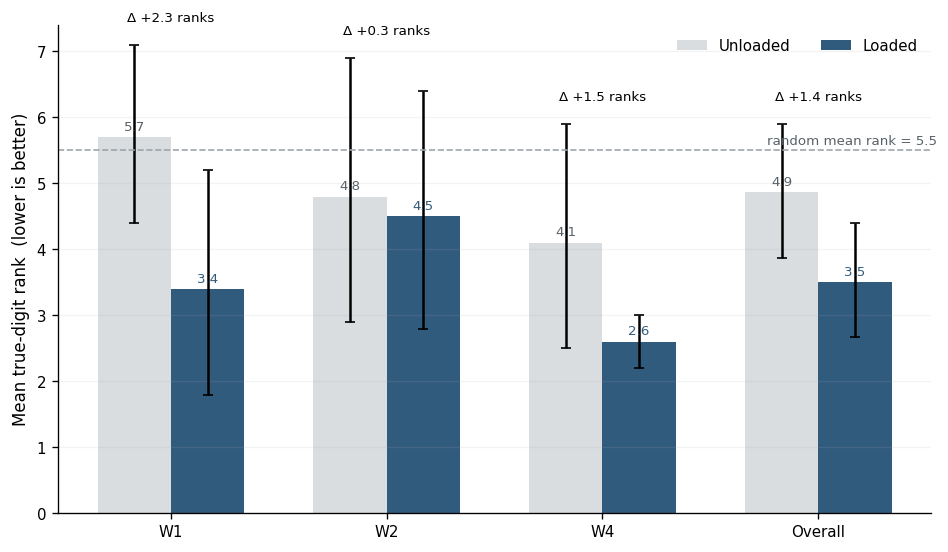

In [26]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DARK_BLUE = "#315B7D"
LIGHT_BLUE = "#C4D5E1"
LIGHT_GREY = "#D9DDE0"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )


def bootstrap_mean_ci(values, seed=20260819, n_boot=20000):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(
        0,
        len(values),
        size=(n_boot, len(values)),
    )
    means = values[idx].mean(axis=1)
    return np.quantile(means, [0.025, 0.975])


rank_plot_rows = []

for scope, g in [
    ("W1", rank_pairs[rank_pairs["wheel"] == 1]),
    ("W2", rank_pairs[rank_pairs["wheel"] == 2]),
    ("W4", rank_pairs[rank_pairs["wheel"] == 4]),
    ("Overall", rank_pairs),
]:
    loaded = g["loaded_true_rank"].to_numpy(dtype=float)
    unloaded = g["unloaded_true_rank"].to_numpy(dtype=float)

    _, p_value = wilcoxon(
        loaded,
        unloaded,
        alternative="less",
        method="auto",
    )

    loaded_ci = bootstrap_mean_ci(
        loaded,
        seed=20260819 + len(rank_plot_rows),
    )
    unloaded_ci = bootstrap_mean_ci(
        unloaded,
        seed=20260829 + len(rank_plot_rows),
    )

    rank_plot_rows.append({
        "scope": scope,
        "loaded_mean": loaded.mean(),
        "loaded_ci_low": loaded_ci[0],
        "loaded_ci_high": loaded_ci[1],
        "unloaded_mean": unloaded.mean(),
        "unloaded_ci_low": unloaded_ci[0],
        "unloaded_ci_high": unloaded_ci[1],
        "improvement": unloaded.mean() - loaded.mean(),
        "p_one_sided": p_value,
    })

rank_plot_summary = pd.DataFrame(rank_plot_rows)

rank_plot_summary.to_csv(
    RESULT_DIR / "RQ2_rank_plot_summary.csv",
    index=False,
)

labels = rank_plot_summary["scope"].tolist()
x = np.arange(len(labels))
width = 0.34

unloaded = rank_plot_summary["unloaded_mean"].to_numpy()
loaded = rank_plot_summary["loaded_mean"].to_numpy()

unloaded_err = np.vstack([
    unloaded - rank_plot_summary["unloaded_ci_low"].to_numpy(),
    rank_plot_summary["unloaded_ci_high"].to_numpy() - unloaded,
])

loaded_err = np.vstack([
    loaded - rank_plot_summary["loaded_ci_low"].to_numpy(),
    rank_plot_summary["loaded_ci_high"].to_numpy() - loaded,
])

fig, ax = plt.subplots(figsize=(8.0, 4.7))

bars_u = ax.bar(
    x - width / 2,
    unloaded,
    width,
    yerr=unloaded_err,
    capsize=3,
    label="Unloaded",
    color=LIGHT_GREY,
    edgecolor="none",
)

bars_l = ax.bar(
    x + width / 2,
    loaded,
    width,
    yerr=loaded_err,
    capsize=3,
    label="Loaded",
    color=DARK_BLUE,
    edgecolor="none",
)

ax.axhline(
    5.5,
    color=MID_GREY,
    linestyle="--",
    linewidth=1,
)

ax.text(
    3.55,
    5.58,
    "random mean rank = 5.5",
    ha="right",
    fontsize=8,
    color=DARK_GREY,
)

for bar, value in zip(bars_u, unloaded):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.10,
        f"{value:.1f}",
        ha="center",
        fontsize=8,
        color=DARK_GREY,
    )

for bar, value in zip(bars_l, loaded):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.10,
        f"{value:.1f}",
        ha="center",
        fontsize=8,
        color=DARK_BLUE,
    )

for i, row in rank_plot_summary.iterrows():
    y = max(
        row["unloaded_ci_high"],
        row["loaded_ci_high"],
    ) + 0.35

    ax.text(
        i,
        y,
        f"Δ {row['improvement']:+.1f} ranks",
        ha="center",
        fontsize=8,
    )

overall_p = float(
    rank_plot_summary.loc[
        rank_plot_summary["scope"] == "Overall",
        "p_one_sided",
    ].iloc[0]
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean true-digit rank  (lower is better)")
ax.set_ylim(0, 7.4)
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper right",
)
ax.grid(axis="y", alpha=0.14)

fig.tight_layout()

save_figure(
    fig,
    "RQ2_Fig1_mean_rank_loaded_vs_unloaded",
)

plt.show()

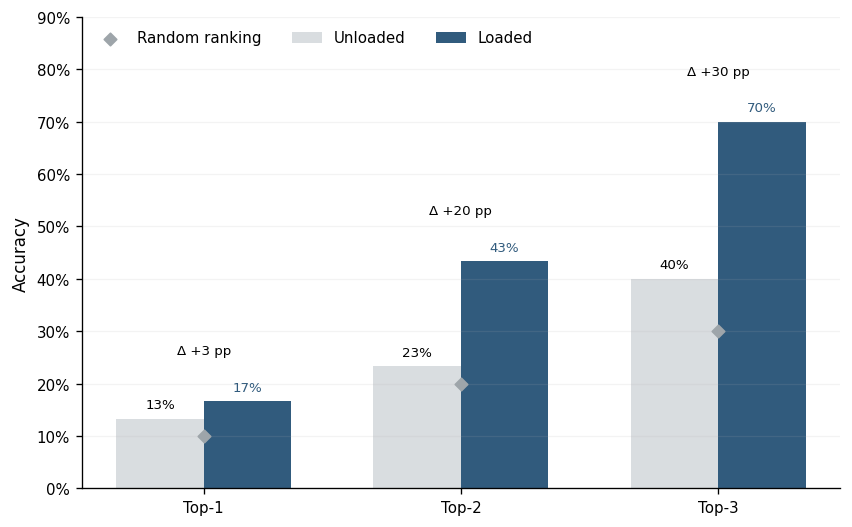

In [27]:
topk_plot = pd.DataFrame({
    "metric": ["Top-1", "Top-2", "Top-3"],
    "unloaded": [
        rank_pairs["unloaded_top1"].mean(),
        rank_pairs["unloaded_top2"].mean(),
        rank_pairs["unloaded_top3"].mean(),
    ],
    "loaded": [
        rank_pairs["loaded_top1"].mean(),
        rank_pairs["loaded_top2"].mean(),
        rank_pairs["loaded_top3"].mean(),
    ],
    "chance": [0.10, 0.20, 0.30],
})

topk_plot.to_csv(
    RESULT_DIR / "RQ2_topk_plot_summary.csv",
    index=False,
)

x = np.arange(3)
width = 0.34

fig, ax = plt.subplots(figsize=(7.2, 4.5))

bars_u = ax.bar(
    x - width / 2,
    100 * topk_plot["unloaded"],
    width,
    label="Unloaded",
    color=LIGHT_GREY,
    edgecolor="none",
)

bars_l = ax.bar(
    x + width / 2,
    100 * topk_plot["loaded"],
    width,
    label="Loaded",
    color=DARK_BLUE,
    edgecolor="none",
)

ax.scatter(
    x,
    100 * topk_plot["chance"],
    marker="D",
    s=28,
    color=MID_GREY,
    zorder=4,
    label="Random ranking",
)

for bar, value in zip(
    bars_u,
    100 * topk_plot["unloaded"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.0f}%",
        ha="center",
        fontsize=8,
    )

for bar, value in zip(
    bars_l,
    100 * topk_plot["loaded"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.0f}%",
        ha="center",
        fontsize=8,
        color=DARK_BLUE,
    )

for i, row in topk_plot.iterrows():
    delta = 100 * (
        row["loaded"]
        - row["unloaded"]
    )

    ax.text(
        i,
        max(
            100 * row["loaded"],
            100 * row["unloaded"],
        ) + 9,
        f"Δ {delta:+.0f} pp",
        ha="center",
        fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(topk_plot["metric"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 90)
ax.set_yticks(np.arange(0, 91, 10))
ax.set_yticklabels([
    f"{v}%"
    for v in np.arange(0, 91, 10)
])
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper left",
)
ax.grid(axis="y", alpha=0.14)

fig.tight_layout()

save_figure(
    fig,
    "RQ2_Fig2_topk_loaded_vs_unloaded",
)

plt.show()

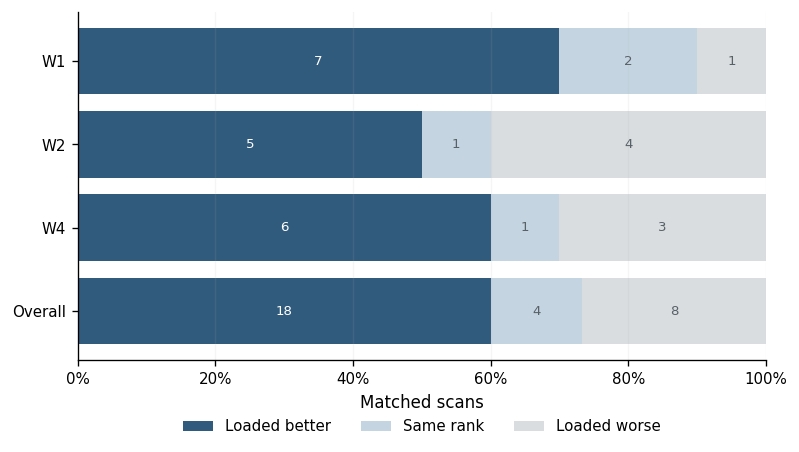

In [28]:
outcome_rows = []

for scope, g in [
    ("W1", rank_pairs[rank_pairs["wheel"] == 1]),
    ("W2", rank_pairs[rank_pairs["wheel"] == 2]),
    ("W4", rank_pairs[rank_pairs["wheel"] == 4]),
    ("Overall", rank_pairs),
]:
    outcome_rows.append({
        "scope": scope,
        "n": len(g),
        "better": int(
            (
                g["loaded_true_rank"]
                < g["unloaded_true_rank"]
            ).sum()
        ),
        "equal": int(
            (
                g["loaded_true_rank"]
                == g["unloaded_true_rank"]
            ).sum()
        ),
        "worse": int(
            (
                g["loaded_true_rank"]
                > g["unloaded_true_rank"]
            ).sum()
        ),
    })

outcome_plot = pd.DataFrame(outcome_rows)

for col in ["better", "equal", "worse"]:
    outcome_plot[f"{col}_pct"] = (
        100
        * outcome_plot[col]
        / outcome_plot["n"]
    )

outcome_plot.to_csv(
    RESULT_DIR / "RQ2_pair_outcome_summary.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7.4, 4.4))

y = np.arange(len(outcome_plot))
left = np.zeros(len(outcome_plot))

segments = [
    ("better_pct", "Loaded better", DARK_BLUE),
    ("equal_pct", "Same rank", LIGHT_BLUE),
    ("worse_pct", "Loaded worse", LIGHT_GREY),
]

for col, label, color in segments:
    values = outcome_plot[col].to_numpy()

    ax.barh(
        y,
        values,
        left=left,
        label=label,
        color=color,
        edgecolor="none",
    )

    count_col = col.replace("_pct", "")
    counts = outcome_plot[count_col].to_numpy()

    for yi, li, value, count in zip(
        y,
        left,
        values,
        counts,
    ):
        if value >= 10:
            ax.text(
                li + value / 2,
                yi,
                str(count),
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if col == "better_pct"
                    else DARK_GREY
                ),
            )

    left += values

ax.set_yticks(y)
ax.set_yticklabels(outcome_plot["scope"])
ax.invert_yaxis()

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels([
    f"{v}%"
    for v in np.arange(0, 101, 20)
])

ax.set_xlabel("Matched scans")
ax.grid(axis="x", alpha=0.12)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
)

fig.subplots_adjust(bottom=0.22)

save_figure(
    fig,
    "RQ2_Fig3_pair_outcomes",
)

plt.show()

In [29]:
# Feature-wise changes are retained as a numerical supplementary result.
# They are saved in RQ2_feature_change.csv rather than used as a main thesis figure.

display(
    feature_change.pivot(
        index="feature",
        columns="wheel",
        values="median_abs_contrast_change",
    ).round(2)
)

wheel,1,2,4
feature,,,
band_0_1k,-0.10,-0.23,0.15
band_1_4k,-0.13,-0.21,0.01
band_4_nyquist,0.02,0.07,-0.17
crest,0.14,-0.14,0.82
derivative_rms,-0.34,-0.14,0.22
peak,0.14,-0.09,0.02
rms,-0.15,-0.08,-0.29
rolloff85_hz,-0.40,0.02,-0.58
spectral_bandwidth_hz,-0.20,0.13,-0.12


## 10. Tables

The CSV files are the editable source; LaTeX copies are saved for the report.

In [30]:
def pct_ci(row, metric):

    return (
        f"{100 * row[metric]:.1f}% "
        f"[{100 * row[f'{metric}_ci_low']:.1f}, "
        f"{100 * row[f'{metric}_ci_high']:.1f}]"
    )


table1_rows = []

for _, row in ranking_summary.iterrows():

    table1_rows.append({
        "Condition": (
            "Loaded"
            if row["state"] == "LOADED"
            else "Unloaded"
        ),
        "Wheel": row["wheel"],
        "N scans": int(
            row["n_scans"]
        ),
        "Top-1 (95% CI)": pct_ci(
            row,
            "top1",
        ),
        "Top-2 (95% CI)": pct_ci(
            row,
            "top2",
        ),
        "Top-3 (95% CI)": pct_ci(
            row,
            "top3",
        ),
        "Mean rank": f"{row['mean_true_rank']:.2f}",
        "MRR": f"{row['mrr']:.3f}",
    })


paper_ranking_table = pd.DataFrame(
    table1_rows
)

paper_ranking_table.to_csv(
    RESULT_DIR / "RQ2_Table1_ranking_summary.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ2_Table1_ranking_summary.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        paper_ranking_table.to_latex(
            index=False,
            escape=True,
        )
    )

display(paper_ranking_table)

,Condition,Wheel,N scans,Top-1 (95% CI),Top-2 (95% CI),Top-3 (95% CI),Mean rank,MRR
0,Loaded,W1,10,"40.0% [16.8, 68.7]","50.0% [23.7, 76.3]","70.0% [39.7, 89.2]",3.40,0.559
1,Loaded,W2,10,"10.0% [1.8, 40.4]","30.0% [10.8, 60.3]","50.0% [23.7, 76.3]",4.50,0.349
2,Loaded,W4,10,"0.0% [0.0, 27.8]","50.0% [23.7, 76.3]","90.0% [59.6, 98.2]",2.60,0.408
3,Loaded,Overall,30,"16.7% [7.3, 33.6]","43.3% [27.4, 60.8]","70.0% [52.1, 83.3]",3.50,0.439
4,Unloaded,W1,10,"0.0% [0.0, 27.8]","0.0% [0.0, 27.8]","20.0% [5.7, 51.0]",5.70,0.205
5,Unloaded,W2,10,"10.0% [1.8, 40.4]","40.0% [16.8, 68.7]","50.0% [23.7, 76.3]",4.80,0.357
6,Unloaded,W4,10,"30.0% [10.8, 60.3]","30.0% [10.8, 60.3]","50.0% [23.7, 76.3]",4.10,0.452
7,Unloaded,Overall,30,"13.3% [5.3, 29.7]","23.3% [11.8, 40.9]","40.0% [24.6, 57.7]",4.87,0.338


In [31]:
rank_test_table = pd.concat(
    [
        overall_rank_test[
            [
                "scope",
                "n_pairs",
                "loaded_mean_rank",
                "unloaded_mean_rank",
                "median_improvement",
                "loaded_better_fraction",
                "p_value",
            ]
        ].rename(
            columns={
                "scope": "Scope",
                "n_pairs": "N pairs",
                "loaded_mean_rank": "Loaded mean rank",
                "unloaded_mean_rank": "Unloaded mean rank",
                "median_improvement": "Median improvement",
                "loaded_better_fraction": "Loaded better",
                "p_value": "p",
            }
        ),
        wheel_rank_tests[
            [
                "wheel",
                "n_pairs",
                "loaded_mean_rank",
                "unloaded_mean_rank",
                "median_improvement",
                "loaded_better_fraction",
                "p_value",
                "p_holm",
            ]
        ].rename(
            columns={
                "wheel": "Scope",
                "n_pairs": "N pairs",
                "loaded_mean_rank": "Loaded mean rank",
                "unloaded_mean_rank": "Unloaded mean rank",
                "median_improvement": "Median improvement",
                "loaded_better_fraction": "Loaded better",
                "p_value": "p",
                "p_holm": "Holm p",
            }
        ),
    ],
    ignore_index=True,
)

rank_test_table["Loaded mean rank"] = (
    rank_test_table[
        "Loaded mean rank"
    ].map(
        lambda x: f"{x:.2f}"
    )
)

rank_test_table["Unloaded mean rank"] = (
    rank_test_table[
        "Unloaded mean rank"
    ].map(
        lambda x: f"{x:.2f}"
    )
)

rank_test_table["Median improvement"] = (
    rank_test_table[
        "Median improvement"
    ].map(
        lambda x: f"{x:.1f}"
    )
)

rank_test_table["Loaded better"] = (
    100
    * rank_test_table[
        "Loaded better"
    ]
).map(
    lambda x: f"{x:.0f}%"
)

rank_test_table["p"] = rank_test_table[
    "p"
].map(
    lambda x: (
        "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

if "Holm p" in rank_test_table.columns:
    rank_test_table["Holm p"] = rank_test_table[
        "Holm p"
    ].map(
        lambda x: (
            ""
            if pd.isna(x)
            else (
                "<0.001"
                if x < 0.001
                else f"{x:.3f}"
            )
        )
    )

rank_test_table.to_csv(
    RESULT_DIR / "RQ2_Table2_matched_rank_tests.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ2_Table2_matched_rank_tests.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        rank_test_table.to_latex(
            index=False,
            escape=True,
        )
    )

display(rank_test_table)

,Scope,N pairs,Loaded mean rank,Unloaded mean rank,Median improvement,Loaded better,p,Holm p
0,Overall,30,3.50,4.87,1.5,60%,0.016,
1,W1,10,3.40,5.70,2.5,70%,0.023,0.070
2,W2,10,4.50,4.80,1.0,50%,0.328,0.328
3,W4,10,2.60,4.10,1.0,60%,0.131,0.262


In [32]:
contrast_table = contrast_test_summary[
    [
        "metric",
        "n_pairs",
        "loaded_median",
        "unloaded_median",
        "median_paired_change",
        "loaded_greater_fraction",
        "p_value",
    ]
].copy()

contrast_table["metric"] = contrast_table[
    "metric"
].map({
    "contrast_rms": "Contrast RMS",
    "median_abs_contrast": "Median |contrast|",
})

contrast_table = contrast_table.rename(
    columns={
        "metric": "Metric",
        "n_pairs": "N pairs",
        "loaded_median": "Loaded median",
        "unloaded_median": "Unloaded median",
        "median_paired_change": "Median change",
        "loaded_greater_fraction": "Loaded greater",
        "p_value": "p",
    }
)

for col in [
    "Loaded median",
    "Unloaded median",
    "Median change",
]:
    contrast_table[col] = contrast_table[
        col
    ].map(
        lambda x: f"{x:.3f}"
    )

contrast_table["Loaded greater"] = (
    100
    * contrast_table[
        "Loaded greater"
    ]
).map(
    lambda x: f"{x:.0f}%"
)

contrast_table["p"] = contrast_table[
    "p"
].map(
    lambda x: f"{x:.3f}"
)

contrast_table.to_csv(
    RESULT_DIR / "RQ2_Table3_contrast_magnitude.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ2_Table3_contrast_magnitude.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        contrast_table.to_latex(
            index=False,
            escape=True,
        )
    )

display(contrast_table)

,Metric,N pairs,Loaded median,Unloaded median,Median change,Loaded greater,p
0,Contrast RMS,30,1.043,1.128,-0.146,40%,0.657
1,Median |contrast|,30,0.731,0.620,-0.017,40%,0.612


## 11. Result record

The final cell saves the main result and the interpretation used in the experiment ledger.

In [33]:
overall_loaded = ranking_summary[
    (ranking_summary["state"] == "LOADED")
    &
    (ranking_summary["wheel"] == "Overall")
].iloc[0]

overall_unloaded = ranking_summary[
    (ranking_summary["state"] == "UNLOADED")
    &
    (ranking_summary["wheel"] == "Overall")
].iloc[0]

contrast_rms_result = contrast_test_summary[
    contrast_test_summary["metric"] == "contrast_rms"
].iloc[0]

median_abs_result = contrast_test_summary[
    contrast_test_summary["metric"] == "median_abs_contrast"
].iloc[0]

rq2_conclusion = {
    "research_question": (
        "Does shackle loading improve true-gate acoustic separability?"
    ),
    "design": (
        "Strictly matched loaded versus unloaded comparison"
    ),
    "password": "3517",
    "direction": "CCW",
    "wheels": [1, 2, 4],
    "n_matched_pairs": int(
        len(rank_pairs)
    ),
    "loaded_mean_true_rank": float(
        overall_loaded["mean_true_rank"]
    ),
    "unloaded_mean_true_rank": float(
        overall_unloaded["mean_true_rank"]
    ),
    "median_rank_improvement": float(
        rank_pairs[
            "rank_improvement"
        ].median()
    ),
    "loaded_better_fraction": float(
        np.mean(
            rank_pairs[
                "loaded_true_rank"
            ]
            <
            rank_pairs[
                "unloaded_true_rank"
            ]
        )
    ),
    "overall_rank_wilcoxon_p": float(
        overall_p
    ),
    "loaded_top1": float(
        overall_loaded["top1"]
    ),
    "unloaded_top1": float(
        overall_unloaded["top1"]
    ),
    "loaded_top2": float(
        overall_loaded["top2"]
    ),
    "unloaded_top2": float(
        overall_unloaded["top2"]
    ),
    "loaded_top3": float(
        overall_loaded["top3"]
    ),
    "unloaded_top3": float(
        overall_unloaded["top3"]
    ),
    "acoustic_contrast_result": {
        "contrast_rms_loaded_median": float(
            contrast_rms_result[
                "loaded_median"
            ]
        ),
        "contrast_rms_unloaded_median": float(
            contrast_rms_result[
                "unloaded_median"
            ]
        ),
        "contrast_rms_p": float(
            contrast_rms_result[
                "p_value"
            ]
        ),
        "median_abs_loaded": float(
            median_abs_result[
                "loaded_median"
            ]
        ),
        "median_abs_unloaded": float(
            median_abs_result[
                "unloaded_median"
            ]
        ),
        "median_abs_p": float(
            median_abs_result[
                "p_value"
            ]
        ),
    },
    "interpretation": (
        "Shackle loading improves true-digit ranking overall: mean rank falls from "
        "4.87 without load to 3.50 under load. The practical effect is most visible "
        "in Top-3 accuracy, which rises from 40% to 70%. The effect is heterogeneous "
        "across wheels and is strongest for W1. Acoustic-contrast magnitude does not "
        "increase uniformly, so the benefit of loading is not simply a louder event."
    ),
    "limitation": (
        "The effect is heterogeneous across wheels. W1 shows the clearest nominal "
        "paired improvement, while the wheel-level tests do not survive Holm correction "
        "at 0.05. Some ranking structure also remains in the unloaded condition, so "
        "loading should not be described as an absolute prerequisite for all acoustic information."
    ),
    "next_step": (
        "RQ3 tests whether the useful acoustic structure is attributable to the lock "
        "rather than motor/transmission sound."
    ),
}

with open(
    RESULT_DIR / "RQ2_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        rq2_conclusion,
        f,
        indent=2,
    )

run_info = {
    "notebook": "02_RQ2_Shackle_Loading.ipynb",
    "dataset": "RQ1-4 controlled validity dataset",
    "truth_source": "pre-specified password 3517",
    "matching": "wheel + scan_start_digit",
    "n_matched_pairs": 30,
    "feature_cache": str(CACHE_PATH),
    "feature_count_used": 13,
    "validation": (
        "leave-one-scan-out separately within each wheel and tension condition"
    ),
    "classifier": {
        "type": "LogisticRegression",
        "C": 1.0,
        "solver": "liblinear",
        "class_weight": "balanced",
        "random_state": 0,
    },
    "primary_test": (
        "one-sided paired Wilcoxon on true-digit rank, loaded < unloaded"
    ),
    "wheel_multiple_testing": (
        "Holm correction across W1/W2/W4 rank tests"
    ),
    "secondary_topk_test": (
        "exact paired McNemar test for Top-1/Top-2/Top-3"
    ),
    "note": (
        "RQ2 controlled validity experiment; not a MAIN model result."
    ),
}

with open(
    RESULT_DIR / "RQ2_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )

print(json.dumps(
    rq2_conclusion,
    indent=2,
))

print("\nSaved outputs:")
for path in sorted(
    RESULT_DIR.glob("RQ2_*")
):
    print(" -", path.name)

{
  "research_question": "Does shackle loading improve true-gate acoustic separability?",
  "design": "Strictly matched loaded versus unloaded comparison",
  "password": "3517",
  "direction": "CCW",
  "wheels": [
    1,
    2,
    4
  ],
  "n_matched_pairs": 30,
  "loaded_mean_true_rank": 3.5,
  "unloaded_mean_true_rank": 4.866666666666666,
  "median_rank_improvement": 1.5,
  "loaded_better_fraction": 0.6,
  "overall_rank_wilcoxon_p": 0.016181005800712505,
  "loaded_top1": 0.16666666666666666,
  "unloaded_top1": 0.13333333333333333,
  "loaded_top2": 0.43333333333333335,
  "unloaded_top2": 0.23333333333333334,
  "loaded_top3": 0.7,
  "unloaded_top3": 0.4,
  "acoustic_contrast_result": {
    "contrast_rms_loaded_median": 1.0425544461987215,
    "contrast_rms_unloaded_median": 1.1284235551784387,
    "contrast_rms_p": 0.657476463355124,
    "median_abs_loaded": 0.731359332057618,
    "median_abs_unloaded": 0.6202630624017695,
    "median_abs_p": 0.6117155831307173
  },
  "interpretation"